In [ ]:
# Install Ultralytics (YOLOv8)
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.6 MB/s eta 0:00:00


In [ ]:
import kagglehub


100%|██████████| 375M/375M [00:18<00:00, 21.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/versions/1


In [ ]:
#Install Required Libraries
import os

for root, dirs, files in os.walk(path):
    print(root)
    break


/root/.cache/kagglehub/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/versions/1


In [ ]:
import os
import kagglehub

# Download dataset to ensure 'path' is defined
download_root_path = kagglehub.dataset_download("nadinpethiyagoda/vehicle-dataset-for-yolo")

# The dataset content (train, valid, test folders) is directly under download_root_path
# So, dataset_actual_path should just be download_root_path
# dataset_actual_path = os.path.join(download_root_path, "vehicle-dataset-for-yolo") # This line was incorrect

# Define the absolute path for vehicle.yaml
yaml_file_path = "/content/vehicle.yaml"

data_yaml = f"""
path: {download_root_path}
train: train/images
val: valid/images
test: test/images

names:
  0: car
  1: motorcycle
  2: bus
  3: truck
"""

with open(yaml_file_path, "w") as f:
    f.write(data_yaml)

print(f"{yaml_file_path} file created")

Using Colab cache for faster access to the 'vehicle-dataset-for-yolo' dataset.
/content/vehicle.yaml file created


In [ ]:
print(path)


/root/.cache/kagglehub/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/versions/1


In [ ]:
import os
os.listdir(path)


['vehicle dataset']

In [ ]:
dataset_path = path + "/vehicle dataset"
print(dataset_path)


/root/.cache/kagglehub/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/versions/1/vehicle dataset


In [ ]:
import os
os.listdir(dataset_path)


['valid', 'train', 'classes.txt']

In [ ]:
import os

print("Train folders:", os.listdir(dataset_path + "/train"))
print("Valid folders:", os.listdir(dataset_path + "/valid"))


Train folders: ['labels', 'images']
Valid folders: ['labels', 'images']


In [ ]:
with open(dataset_path + "/classes.txt", "r") as f:
    class_names = f.read().splitlines()

print(class_names)


['car', 'threewheel', 'bus', 'truck', 'motorbike', 'van']


In [ ]:
#Load YOLO Model
data_yaml = f"""
path: {dataset_path}
train: train/images
val: valid/images

names:
"""

for i, name in enumerate(class_names):
    data_yaml += f"  {i}: {name}\n"

with open("/content/vehicle.yaml", "w") as f:
    f.write(data_yaml)

print("YAML created successfully")


YAML created successfully


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/vehicle.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicle.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7da4a6c038f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
import os
os.listdir("runs/detect/train/weights")


['best.pt', 'last.pt']

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

metrics = model.val()
print(metrics)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2251.4±845.7 MB/s, size: 89.8 KB)
val: Scanning /root/.cache/kagglehub/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/versions/1/vehicle dataset/valid/labels.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900 377.5Mit/s 0.0s
val: /root/.cache/kagglehub/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo/versions/1/vehicle dataset/valid/images/car55.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 6.0it/s 9.4s
                   all        900       1150      0.971      0.941      0.979      0.909
                   car        182        201      0.953      0.925      0.971      0.939
            threewheel        167        227          1      0.939   

In [ ]:
from ultralytics import YOLO
from google.colab import files

# Ensure ultralytics is installed
!pip install ultralytics

# Upload the image file
uploaded = files.upload()

# Load the best trained model from the correct path
model = YOLO("runs/detect/train/weights/best.pt")

# Perform prediction on the uploaded image
results = model.predict(
    source=list(uploaded.keys())[0],
    conf=0.4
)

# Extract and print the number of detected vehicles
boxes = results[0].boxes
print("Total Vehicles Detected:", len(boxes))


Saving Preference_for_pvt_vehicles.jpg to Preference_for_pvt_vehicles (1).jpg

image 1/1 /content/Preference_for_pvt_vehicles (1).jpg: 320x640 4 cars, 2 threewheels, 45.7ms
Speed: 1.5ms preprocess, 45.7ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
Total Vehicles Detected: 6


In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

results = model.predict(
    source=list(uploaded.keys())[0],
    save=True,
    conf=0.4
)


image 1/1 /content/images (12).jpg: 448x640 2 threewheels, 1 motorbike, 41.6ms
Speed: 1.7ms preprocess, 41.6ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


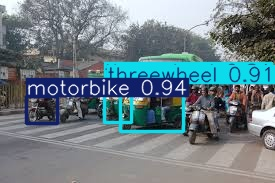

In [ ]:
from IPython.display import Image
Image("runs/detect/predict/" + list(uploaded.keys())[0])


Saving istockphoto-1191967049-612x612.jpg to istockphoto-1191967049-612x612.jpg


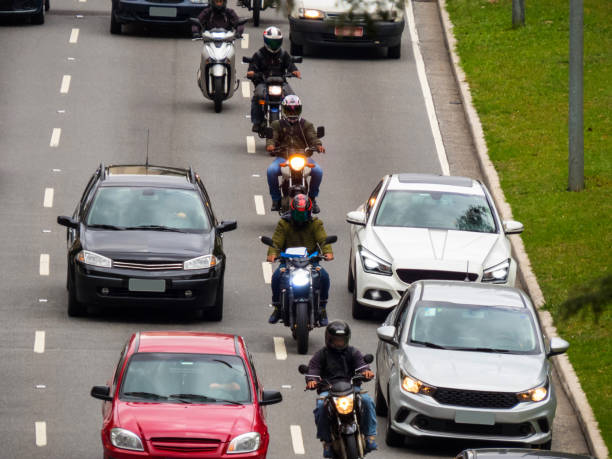

In [ ]:
from google.colab import files
from IPython.display import Image, display

# Upload image
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Display image
display(Image(filename=file_name))


In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

results = model.predict(
    source=list(uploaded.keys())[0],
    save=True,
    conf=0.4
)


image 1/1 /content/istockphoto-1191967049-612x612.jpg: 480x640 6 cars, 3 motorbikes, 1 van, 39.1ms
Speed: 2.7ms preprocess, 39.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict2


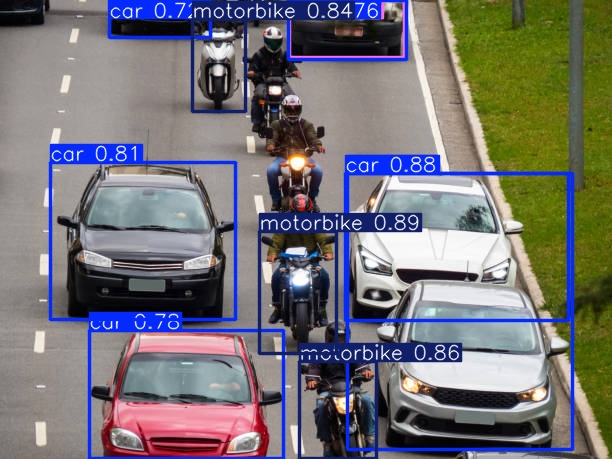

In [ ]:
from IPython.display import Image
Image("runs/detect/predict2/" + list(uploaded.keys())[0])